# Ejercicio 3. Despacho óptimo de energía eléctrica

Curso de Inteligencia Artificial. Capítulo 3, Algoritmos Genéticos (José J. Martínez P.)

Ejercicio 3.10, numeral 3.

---

## 1. Definición del problema

Una empresa proveedora de energía dispone de cuatro plantas de generación y debe satisfacer la
demanda diaria de cuatro ciudades. Se requiere determinar cuánta energía envía cada planta a
cada ciudad, de manera que el costo total, entendido como la suma del costo de generación y el
costo de transporte, sea mínimo.

| Generador | Capacidad (GW/día) | Costo \$/KW-H |
|---|---|---|
| Planta C | 3 | 680 |
| Planta B | 6 | 720 |
| Planta M | 5 | 660 |
| Planta B | 4 | 750 |

| Ciudad | Demanda (GW/día) |
|---|---|
| Cali | 4 |
| Bogotá | 3 |
| Medellín | 5 |
| Barranquilla | 3 |

Costos de transporte por unidad de energía entre plantas y ciudades:

|  | Cali | Bogotá | Medellín | Barranq. |
|---|---|---|---|---|
| Planta C | 1 | 4 | 3 | 6 |
| Planta B | 4 | 1 | 4 | 5 |
| Planta M | 3 | 4 | 1 | 4 |
| Planta B | 6 | 5 | 4 | 1 |

### Nota sobre la nomenclatura de las plantas

El enunciado nombra **dos plantas distintas con la misma etiqueta, "Planta B"**: la segunda y la
cuarta fila de ambas tablas. Se trata en efecto de dos generadores diferentes, puesto que tienen
capacidades distintas (6 y 4 GW/día), costos de generación distintos (720 y 750 \$/KW-H) y filas
de transporte distintas. Los nombres se conservan tal como aparecen en el enunciado, y para
evitar cualquier ambigüedad en el código y en las tablas de resultados las plantas se numeran
**P1 a P4** siguiendo el orden en que aparecen:

| Índice | Nombre en el enunciado | Capacidad | Costo de generación |
|---|---|---|---|
| P1 | Planta C | 3 GW/día | 680 \$/KW-H |
| P2 | Planta B | 6 GW/día | 720 \$/KW-H |
| P3 | Planta M | 5 GW/día | 660 \$/KW-H |
| P4 | Planta B | 4 GW/día | 750 \$/KW-H |

### Observación sobre las unidades

En el enunciado la tabla de generación está expresada en \$/KW-H mientras que la de transporte
se refiere a cada GW. Para que ambas cantidades sean sumables se toman las dos en \$/kWh, lo
cual corresponde a órdenes de magnitud realistas en pesos colombianos: entre 660 y 750 \$/kWh de
generación, y entre 1 y 6 \$/kWh de peaje de transmisión según la ruta. El costo diario se
obtiene multiplicando por los $24\times10^{6}$ kWh que contiene un GW·día. La estructura del
problema y su solución óptima no dependen de esta escala.

La capacidad total instalada es de 18 GW y la demanda total es de 15 GW, de modo que el sistema
está sobreofertado. Además de repartir la energía, el algoritmo debe decidir qué capacidad deja
de utilizarse. Se trata de un problema de transporte con costos de generación, perteneciente a
la familia de los problemas de asignación mencionados en la sección 3.6 del capítulo.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(3)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# Nombres tal como aparecen en el enunciado. La segunda y la cuarta planta se llaman
# ambas "Planta B", por lo que se antepone el indice P1..P4 para distinguirlas.
PLANTAS  = ["P1 Planta C", "P2 Planta B", "P3 Planta M", "P4 Planta B"]
CIUDADES = ["Cali", "Bogotá", "Medellín", "Barranquilla"]

CAPACIDAD = np.array([3.0, 6.0, 5.0, 4.0])           # GW/dia que puede generar cada planta
DEMANDA   = np.array([4.0, 3.0, 5.0, 3.0])           # GW/dia que requiere cada ciudad
C_GEN     = np.array([680.0, 720.0, 660.0, 750.0])   # $/kWh de generacion

C_TRANS = np.array([                                 # $/kWh de transporte planta a ciudad
    [1., 4., 3., 6.],
    [4., 1., 4., 5.],
    [3., 4., 1., 4.],
    [6., 5., 4., 1.],
])

# Costo unitario total de llevar un kWh de la planta i a la ciudad j
C_UNIT = C_GEN[:, None] + C_TRANS
KWH_POR_GW_DIA = 24e6

print("Costo unitario total C_ij = generacion + transporte  [$/kWh]")
print(pd.DataFrame(C_UNIT, index=PLANTAS, columns=CIUDADES).to_string())
print(f"\nCapacidad total = {CAPACIDAD.sum():.0f} GW   Demanda total = {DEMANDA.sum():.0f} GW"
      f"   Excedente = {CAPACIDAD.sum()-DEMANDA.sum():.0f} GW")
print(f"\nDiferencia maxima entre costos de generacion : {C_GEN.max()-C_GEN.min():.0f} $/kWh")
print(f"Diferencia maxima entre costos de transporte : {C_TRANS.max()-C_TRANS.min():.0f} $/kWh")

Costo unitario total C_ij = generacion + transporte  [$/kWh]
              Cali  Bogotá  Medellín  Barranquilla
P1 Planta C  681.0   684.0     683.0         686.0
P2 Planta B  724.0   721.0     724.0         725.0
P3 Planta M  663.0   664.0     661.0         664.0
P4 Planta B  756.0   755.0     754.0         751.0

Capacidad total = 18 GW   Demanda total = 15 GW   Excedente = 3 GW

Diferencia maxima entre costos de generacion : 90 $/kWh
Diferencia maxima entre costos de transporte : 5 $/kWh

## 2. Representación de los individuos

La solución del problema es una matriz de despacho $X$ de tamaño $4\times4$, donde $x_{ij}$ es
la energía, en GW/día, que la planta $i$ envía a la ciudad $j$. Esta matriz debe satisfacer dos
condiciones:

$$\sum_{i} x_{ij} = d_j \quad \forall j \qquad \text{(la demanda se satisface exactamente)}$$

$$\sum_{j} x_{ij} \le \mathrm{cap}_i \quad \forall i \qquad \text{(no se excede la capacidad)}$$

El capítulo señala que los genes pueden ser binarios, enteros, reales o lógicos. Como las
cantidades despachadas son continuas, se emplean genes reales. El cromosoma es un vector de
dieciséis números positivos $p_{ij}$ que se interpretan como prioridades, y la decodificación
reparte la demanda de cada ciudad entre las plantas en proporción a esas prioridades:

$$x_{ij} = d_j\,\frac{p_{ij}}{\sum_k p_{kj}}$$

Esta decodificación garantiza por construcción que la demanda se satisface de forma exacta. La
única restricción que puede violarse es la de capacidad, y su tratamiento se aborda en la
sección 4.

In [2]:
NP_, NC = 4, 4
NGENES = NP_ * NC

def genera(K):
    "Poblacion inicial: prioridades reales en el intervalo (0,1]."
    return rng.random((K, NGENES)) + 1e-6

def decodifica(crom):
    "Vector de 16 prioridades a matriz de despacho X (4x4) en GW/dia."
    P = np.clip(crom.reshape(NP_, NC), 1e-9, None)
    return P / P.sum(axis=0, keepdims=True) * DEMANDA     # normaliza por columna (ciudad)

X0 = decodifica(genera(1)[0])
print("Matriz de despacho de un cromosoma aleatorio (GW/dia):")
print(pd.DataFrame(np.round(X0, 3), index=PLANTAS, columns=CIUDADES).to_string())
print("\nSuma por ciudad (debe igualar la demanda):", np.round(X0.sum(axis=0), 6))
print("Suma por planta                           :", np.round(X0.sum(axis=1), 3))
print("Capacidad disponible                      :", CAPACIDAD)

Matriz de despacho de un cromosoma aleatorio (GW/dia):
              Cali  Bogotá  Medellín  Barranquilla
P1 Planta C  0.255   0.518     1.663         0.789
P2 Planta B  0.280   0.948     0.994         0.216
P3 Planta M  2.185   0.249     0.812         0.700
P4 Planta B  1.281   1.285     1.531         1.295

Suma por ciudad (debe igualar la demanda): [4. 3. 5. 3.]
Suma por planta                           : [3.224 2.439 3.945 5.392]
Capacidad disponible                      : [3. 6. 5. 4.]

## 3. Operadores genéticos

El capítulo indica que, dependiendo del dominio del problema, se deben definir y adecuar los
operadores genéticos que se van a utilizar. Con genes reales los operadores binarios no son
aplicables, de modo que se emplean sus equivalentes continuos:

1. Selección por torneo de tamaño 3. Se escogen tres cromosomas al azar y se conserva el de
   mayor aptitud. A diferencia de la ruleta, este mecanismo no depende de la escala de la
   aptitud, propiedad conveniente en un problema cuyos costos son del orden de $10^{11}$.
2. Cruce BLX-$\alpha$ con $\alpha = 0.4$. Cada gen del hijo se toma al azar dentro del intervalo
   $[\min(p_1,p_2)-\alpha I,\ \max(p_1,p_2)+\alpha I]$, siendo $I = |p_1 - p_2|$. La extensión
   del intervalo más allá del rango de los padres es lo que dota de capacidad exploratoria al
   cruce real, pues una combinación lineal simple solamente interpola.
3. Mutación gaussiana. Con probabilidad $p_m$ se le suma al gen un ruido $\mathcal{N}(0,\sigma)$
   con $\sigma$ decreciente a lo largo de las generaciones. Corresponde a la mutación variable
   descrita en la sección 3.8.6: la probabilidad de exploración es alta al comienzo y disminuye
   a medida que avanza el proceso, lo que favorece el ajuste fino en las últimas generaciones.

Se conserva elitismo de tres individuos.

In [3]:
K      = 150     # tamaño de la poblacion
M      = 600     # numero de generaciones
P_MUT  = 0.15    # probabilidad de mutacion por gen
ALPHA  = 0.4     # parametro del cruce BLX
ELITE  = 3

def seleccion_torneo(pob, apt, t=3):
    idx = rng.integers(0, len(pob), size=(len(pob), t))
    gan = idx[np.arange(len(pob)), np.argmax(apt[idx], axis=1)]
    return pob[gan].copy()

def cruce_blx(padres, alpha=ALPHA):
    hijos = padres.copy()
    for i in range(0, len(padres) - 1, 2):
        p1, p2 = padres[i], padres[i+1]
        lo, hi = np.minimum(p1, p2), np.maximum(p1, p2)
        I = hi - lo
        hijos[i]   = rng.uniform(lo - alpha*I, hi + alpha*I)
        hijos[i+1] = rng.uniform(lo - alpha*I, hi + alpha*I)
    return np.clip(hijos, 1e-6, None)

def mutacion(hijos, p_mut, sigma):
    m = rng.random(hijos.shape) < p_mut
    hijos[m] += rng.normal(0, sigma, size=int(m.sum()))
    return np.clip(hijos, 1e-6, None)

## 4. Función de aptitud y tratamiento de las restricciones

El costo total asociado a una matriz de despacho es

$$\text{Costo}(X) = \sum_{i}\sum_{j} x_{ij}\,(g_i + t_{ij})\cdot 24\times10^{6}
\qquad [\$/\text{día}]$$

Las soluciones que exceden la capacidad de alguna planta violan una restricción del problema. La
sección 3.8 del capítulo plantea tres enfoques posibles: eliminación, penalidad alta y penalidad
moderada. Se adopta la penalidad moderada, que es la misma que el capítulo emplea en el problema
del furgón, donde la penalidad es un múltiplo del exceso de peso:

$$\text{exceso} = \sum_i \max\!\left(0,\ \sum_j x_{ij} - \mathrm{cap}_i\right)$$

$$f_{apt}(X) = -\big[\text{Costo}(X) + 3\,\bar{c}\,\text{exceso}\cdot 24\times10^{6}\big]$$

donde $\bar{c}$ es el mayor costo unitario. La penalidad es moderada en el sentido de que no
elimina al infractor sino que reduce su aptitud, de manera que un cromosoma que viole ligeramente
la capacidad puede seguir aportando material genético útil a las generaciones siguientes. Este
es el comportamiento que el capítulo describe como deseable para evitar que el algoritmo pase
por alto soluciones válidas cercanas a la frontera.

In [4]:
PEN = 3 * C_UNIT.max()      # penalidad moderada: tres veces el peor costo unitario

def costo_y_exceso(pob):
    "Costo diario en pesos y exceso de capacidad en GW, para toda la poblacion."
    P = np.clip(pob.reshape(-1, NP_, NC), 1e-9, None)
    X = P / P.sum(axis=1, keepdims=True) * DEMANDA           # decodificacion vectorizada
    costo  = (X * C_UNIT).sum(axis=(1, 2)) * KWH_POR_GW_DIA
    exceso = np.maximum(0, X.sum(axis=2) - CAPACIDAD).sum(axis=1)
    return costo, exceso, X

def evalua(pob):
    costo, exceso, X = costo_y_exceso(pob)
    penalizado = costo + PEN * exceso * KWH_POR_GW_DIA
    return -penalizado, costo, exceso, X       # aptitud = costo penalizado con signo negativo

## 5. Criterio de parada, población y rutina principal

Se adopta como criterio de parada un número fijo de 600 generaciones, con una población de 150
cromosomas. El tamaño de la población es mayor que en el ejercicio 1 porque el espacio de
búsqueda es continuo y de dieciséis dimensiones. En cada generación se registra el mejor costo
entre las soluciones factibles, es decir, aquellas cuyo exceso de capacidad es nulo.

In [5]:
def algoritmo_genetico(K=K, M=M, p_mut=P_MUT, semilla=None):
    global rng
    if semilla is not None:
        rng = np.random.default_rng(semilla)

    pob = genera(K)
    hist_mejor, hist_prom = [], []
    mejor = dict(costo=np.inf)

    for gen in range(M):
        apt, costo, exceso, X = evalua(pob)
        factibles = exceso < 1e-6
        if factibles.any():
            i = int(np.where(factibles, costo, np.inf).argmin())
            if costo[i] < mejor["costo"]:
                mejor = dict(costo=float(costo[i]), X=X[i].copy(),
                             crom=pob[i].copy(), gen=gen)
        hist_mejor.append(mejor["costo"])
        hist_prom.append(float(costo.mean()))

        sigma  = 0.35 * (1 - gen / M) + 0.01      # mutacion variable (sigma decreciente)
        orden  = np.argsort(-apt)
        elites = pob[orden[:ELITE]].copy()
        hijos  = mutacion(cruce_blx(seleccion_torneo(pob, apt)), p_mut, sigma)
        hijos[:ELITE] = elites
        pob = hijos

    mejor["hist_mejor"] = np.array(hist_mejor)
    mejor["hist_prom"]  = np.array(hist_prom)
    return mejor

res = algoritmo_genetico(semilla=3)
print(f"Mejor costo encontrado : $ {res['costo']:,.0f} por dia   "
      f"(hallado en la generacion {res['gen']})")

Mejor costo encontrado : $ 251,040,881,716 por dia   (hallado en la generacion 575)

## 6. Resultados de la primera versión

In [6]:
X = np.round(res["X"], 4)
desp = pd.DataFrame(X, index=PLANTAS, columns=CIUDADES)
desp["Generado"]  = X.sum(axis=1).round(3)
desp["Capacidad"] = CAPACIDAD
desp["Ocioso"]    = (CAPACIDAD - X.sum(axis=1)).round(3)
print("Despacho obtenido (GW/dia)")
print(desp.to_string())
print("\nSuma recibida por ciudad :", np.round(X.sum(axis=0), 4))
print("Demanda requerida        :", DEMANDA)

costo_gen   = (X.sum(axis=1) * C_GEN).sum() * KWH_POR_GW_DIA
costo_trans = (X * C_TRANS).sum() * KWH_POR_GW_DIA
print(f"\nCosto de generacion : $ {costo_gen:>18,.0f} por dia")
print(f"Costo de transporte : $ {costo_trans:>18,.0f} por dia")
print(f"Costo total         : $ {costo_gen + costo_trans:>18,.0f} por dia")

Despacho obtenido (GW/dia)
               Cali  Bogotá  Medellín  Barranquilla  Generado  Capacidad  Ocioso
P1 Planta C  0.2928  0.4158    1.6135        0.6750     2.997        3.0   0.003
P2 Planta B  2.6328  0.8638    1.3676        1.1213     5.986        6.0   0.014
P3 Planta M  1.0744  1.6693    1.6960        0.5597     4.999        5.0   0.001
P4 Planta B  0.0000  0.0511    0.3229        0.6440     1.018        4.0   2.982

Suma recibida por ciudad : [4. 3. 5. 3.]
Demanda requerida        : [4. 3. 5. 3.]

Costo de generacion : $    249,856,608,000 por dia
Costo de transporte : $      1,184,272,800 por dia
Costo total         : $    251,040,880,800 por dia

## 7. Verificación contra la solución exacta

El problema, tal como está planteado, es un problema de transporte lineal, de modo que admite
solución exacta por programación lineal mediante el método símplex. Adicionalmente, dado que las
capacidades y las demandas son números enteros, el óptimo de la relajación lineal también es
entero, lo que permite una segunda verificación independiente por enumeración completa de los
despachos enteros posibles.

In [7]:
from scipy.optimize import linprog

c = (C_UNIT * KWH_POR_GW_DIA).ravel()
A_eq = np.zeros((NC, NGENES));  b_eq = DEMANDA          # demanda exacta por ciudad
for j in range(NC):
    for i in range(NP_):
        A_eq[j, i*NC + j] = 1
A_ub = np.zeros((NP_, NGENES)); b_ub = CAPACIDAD        # capacidad por planta
for i in range(NP_):
    A_ub[i, i*NC:(i+1)*NC] = 1

lp = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq,
             bounds=[(0, None)]*NGENES, method="highs")
X_lp = lp.x.reshape(NP_, NC)

print("Despacho optimo exacto por programacion lineal (GW/dia):")
print(pd.DataFrame(np.round(X_lp, 4), index=PLANTAS, columns=CIUDADES).to_string())
print(f"\nCosto optimo exacto : $ {lp.fun:,.0f} por dia")
print(f"Costo de la version 1 del AG : $ {res['costo']:,.0f} por dia")
print(f"Diferencia : $ {res['costo']-lp.fun:,.0f}  "
      f"({(res['costo']-lp.fun)/lp.fun*100:.4f} %)")

Despacho optimo exacto por programacion lineal (GW/dia):
             Cali  Bogotá  Medellín  Barranquilla
P1 Planta C   3.0     0.0       0.0           0.0
P2 Planta B   1.0     3.0       0.0           2.0
P3 Planta M  -0.0     0.0       5.0           0.0
P4 Planta B   0.0     0.0       0.0           1.0

Costo optimo exacto : $ 250,464,000,000 por dia
Costo de la version 1 del AG : $ 251,040,881,716 por dia
Diferencia : $ 576,881,716  (0.2303 %)

In [8]:
from itertools import product

def composiciones(total, partes):
    "Todas las formas enteras de repartir 'total' en 'partes' sumandos no negativos."
    if partes == 1:
        yield (total,); return
    for k in range(total + 1):
        for resto in composiciones(total - k, partes - 1):
            yield (k,) + resto

opciones = [list(composiciones(int(d), NP_)) for d in DEMANDA]
print("Combinaciones posibles por ciudad:", [len(o) for o in opciones],
      "  Total de despachos enteros:", np.prod([len(o) for o in opciones]))

mejor_costo, mejor_X = np.inf, None
for combo in product(*opciones):
    Xe = np.array(combo).T.astype(float)         # (planta, ciudad)
    if np.any(Xe.sum(axis=1) > CAPACIDAD):
        continue
    cst = (Xe * C_UNIT).sum() * KWH_POR_GW_DIA
    if cst < mejor_costo:
        mejor_costo, mejor_X = cst, Xe

print(f"\nMejor despacho entero por fuerza bruta: $ {mejor_costo:,.0f} por dia")
print(pd.DataFrame(mejor_X.astype(int), index=PLANTAS, columns=CIUDADES).to_string())
print(f"\nCoincide con la programacion lineal: {abs(mejor_costo - lp.fun) < 1}")

Combinaciones posibles por ciudad: [35, 20, 56, 20]   Total de despachos enteros: 784000

Mejor despacho entero por fuerza bruta: $ 250,464,000,000 por dia
             Cali  Bogotá  Medellín  Barranquilla
P1 Planta C     3       0         0             0
P2 Planta B     1       3         0             2
P3 Planta M     0       0         5             0
P4 Planta B     0       0         0             1

Coincide con la programacion lineal: True

## 8. Rediseño de la representación

La primera versión del algoritmo se sitúa aproximadamente a 0.23 % del óptimo. La causa no es el
número de generaciones ni el tamaño de la población, sino la representación escogida.

El óptimo de un problema de transporte se encuentra siempre en un vértice del poliedro de
soluciones factibles, lo que implica que muchas de las variables $x_{ij}$ valen exactamente cero
y que las plantas utilizadas trabajan a plena capacidad. La decodificación proporcional, en
cambio, reparte la demanda de cada ciudad entre todas las plantas, de modo que alcanzar un cero
exacto exigiría que una prioridad se anulara por completo, situación que la mutación gaussiana
prácticamente nunca produce.

El capítulo advierte que los pasos del diseño de un algoritmo genético "son una guía, dado que
en cualquier momento, dependiendo del comportamiento del algoritmo genético, se debe volver a
algunos pasos anteriores para afinar ese comportamiento". Se regresa entonces al paso 2 y se
sustituye la decodificación proporcional por una decodificación voraz:

- Dieciséis genes representan la prioridad de cada planta para cada ciudad.
- Cuatro genes adicionales definen el orden en que se atienden las ciudades.
- Cada ciudad toma su demanda de las plantas en orden de prioridad descendente, hasta agotar la
  capacidad disponible de cada una.

Como la capacidad total supera a la demanda total, esta decodificación produce siempre
soluciones factibles, lo que elimina la necesidad de la penalidad, y produce además soluciones
de vértice, que es precisamente donde se encuentra el óptimo.

In [9]:
NGENES2 = NP_ * NC + NC          # 16 prioridades mas 4 claves de orden de las ciudades

def decodifica_voraz(crom):
    "Decodificacion voraz: produce siempre soluciones factibles y de vertice."
    prio  = crom[:NP_*NC].reshape(NP_, NC)
    orden = np.argsort(-crom[NP_*NC:])          # orden en que se atienden las ciudades
    rem = CAPACIDAD.copy()
    X = np.zeros((NP_, NC))
    for j in orden:
        d = DEMANDA[j]
        for i in np.argsort(-prio[:, j]):       # plantas por prioridad descendente
            if d <= 1e-12: break
            t = min(d, rem[i])
            X[i, j] += t; rem[i] -= t; d -= t
    return X

def evalua2(pob):
    X = np.array([decodifica_voraz(c) for c in pob])
    costo = (X * C_UNIT).sum(axis=(1, 2)) * KWH_POR_GW_DIA
    return -costo, costo, X

def algoritmo_genetico2(K=K, M=300, p_mut=P_MUT, semilla=None):
    global rng
    if semilla is not None:
        rng = np.random.default_rng(semilla)
    pob = rng.random((K, NGENES2)) + 1e-6
    hist, mejor = [], dict(costo=np.inf)
    for gen in range(M):
        apt, costo, X = evalua2(pob)
        i = int(costo.argmin())
        if costo[i] < mejor["costo"]:
            mejor = dict(costo=float(costo[i]), X=X[i].copy(), gen=gen)
        hist.append(mejor["costo"])
        sigma  = 0.35 * (1 - gen / M) + 0.01
        orden  = np.argsort(-apt)
        elites = pob[orden[:ELITE]].copy()
        hijos  = mutacion(cruce_blx(seleccion_torneo(pob, apt)), p_mut, sigma)
        hijos[:ELITE] = elites
        pob = hijos
    mejor["hist"] = np.array(hist)
    return mejor

res2 = algoritmo_genetico2(semilla=3)
print("Despacho obtenido con la decodificacion voraz (GW/dia):")
print(pd.DataFrame(np.round(res2["X"], 3), index=PLANTAS, columns=CIUDADES).to_string())
print(f"\nCosto del AG version 2 : $ {res2['costo']:,.0f} por dia "
      f"(hallado en la generacion {res2['gen']})")
print(f"Optimo exacto          : $ {lp.fun:,.0f} por dia")
print(f"Diferencia             : {(res2['costo']-lp.fun)/lp.fun*100:.8f} %")

Despacho obtenido con la decodificacion voraz (GW/dia):
             Cali  Bogotá  Medellín  Barranquilla
P1 Planta C   3.0     0.0       0.0           0.0
P2 Planta B   1.0     3.0       0.0           2.0
P3 Planta M   0.0     0.0       5.0           0.0
P4 Planta B   0.0     0.0       0.0           1.0

Costo del AG version 2 : $ 250,464,000,000 por dia (hallado en la generacion 3)
Optimo exacto          : $ 250,464,000,000 por dia
Diferencia             : 0.00000000 %

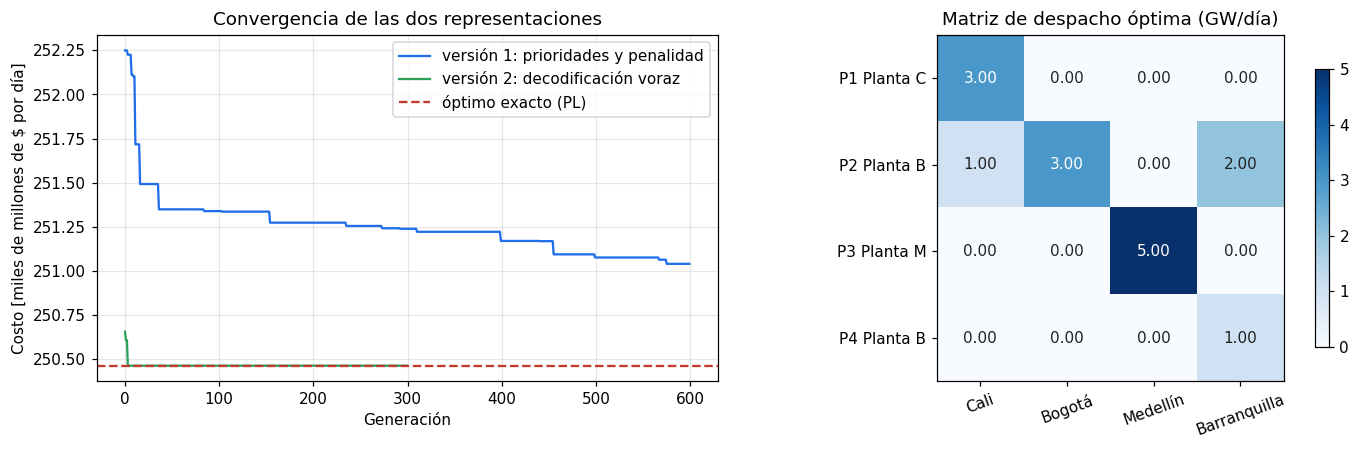

In [10]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.2))

a1.plot(res["hist_mejor"] / 1e9, color="#1f6feb", label="versión 1: prioridades y penalidad")
a1.plot(res2["hist"] / 1e9, color="#2e9e5b", label="versión 2: decodificación voraz")
a1.axhline(lp.fun / 1e9, color="#c0392b", ls="--", label="óptimo exacto (PL)")
a1.set_xlabel("Generación"); a1.set_ylabel("Costo [miles de millones de \\$ por día]")
a1.set_title("Convergencia de las dos representaciones"); a1.legend()

im = a2.imshow(res2["X"], cmap="Blues")
a2.set_xticks(range(NC)); a2.set_xticklabels(CIUDADES, rotation=20)
a2.set_yticks(range(NP_)); a2.set_yticklabels(PLANTAS)
for i in range(NP_):
    for j in range(NC):
        v = res2["X"][i, j]
        a2.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="white" if v > 2.5 else "#222", fontsize=10)
a2.set_title("Matriz de despacho óptima (GW/día)"); a2.grid(False)
plt.colorbar(im, ax=a2, shrink=0.8)
plt.tight_layout(); plt.show()

## 9. Comparación de las dos representaciones

Se ejecutan diez corridas independientes de cada versión, con semillas distintas, para comparar
su desempeño de manera estadística y no sobre una sola ejecución.

In [11]:
c1 = np.array([algoritmo_genetico(semilla=s)["costo"]  for s in range(50, 60)])
c2 = np.array([algoritmo_genetico2(semilla=s)["costo"] for s in range(50, 60)])
g1, g2 = (c1 - lp.fun)/lp.fun*100, (c2 - lp.fun)/lp.fun*100

print(f"{'Version':<36}{'diferencia media':>18}{'mejor':>12}{'peor':>12}{'exactas':>10}")
print("-" * 90)
print(f"{'v1 prioridades y penalidad':<36}{g1.mean():>17.6f}%{g1.min():>11.6f}%"
      f"{g1.max():>11.6f}%{(g1<1e-6).sum():>8}/10")
print(f"{'v2 decodificacion voraz':<36}{g2.mean():>17.6f}%{g2.min():>11.6f}%"
      f"{g2.max():>11.6f}%{(g2<1e-6).sum():>8}/10")
print("-" * 90)

Version                               diferencia media       mejor        peor   exactas
------------------------------------------------------------------------------------------
v1 prioridades y penalidad                   0.168231%   0.116124%   0.248023%       0/10
v2 decodificacion voraz                      0.000000%   0.000000%   0.000000%      10/10
------------------------------------------------------------------------------------------

## 10. Análisis del resultado

El despacho óptimo asigna la totalidad de la capacidad de las tres plantas más económicas, la
Planta M a 660 \$/kWh, la Planta C a 680 \$/kWh y la Planta B a 720 \$/kWh, y deja ociosos tres
de los cuatro GW de P4, que es la planta más costosa con 750 \$/kWh.

Este comportamiento se explica por la estructura de los costos. Las diferencias entre los costos
de generación alcanzan 90 \$/kWh, mientras que las diferencias entre los costos de transporte no
superan 5 \$/kWh. El costo de generación domina por tanto la decisión de cuánto genera cada
planta, y el costo de transporte determina únicamente el detalle de qué planta atiende a qué
ciudad. Puede comprobarse en la matriz obtenida: P1 entrega sus 3 GW a Cali, que es su destino más
barato, y P3 entrega sus 5 GW a Medellín por la misma razón.

## 11. Conclusiones

El primer resultado del ejercicio es que la representación de los individuos pesa más que los
parámetros del algoritmo. La versión inicial, con prioridades normalizadas y penalidad moderada,
se mantuvo en promedio a 0.17 % del óptimo en las diez corridas y ninguna alcanzó la solución
exacta. Al regresar al paso 2 del diseño y sustituir la decodificación, el algoritmo encontró el
óptimo exacto en las diez corridas, y en la ejecución presentada lo hizo en la generación 3. El
factor limitante no era la población ni la probabilidad de mutación, sino la forma de codificar
la solución.

El óptimo hallado coincide con el obtenido por programación lineal y con el de la enumeración
completa de los 784 000 despachos enteros posibles, lo que confirma la corrección del resultado
por dos vías independientes entre sí.

La decodificación por prioridades normalizadas asegura el cumplimiento de la restricción de
demanda, y la penalidad moderada de la sección 3.8 basta para que la restricción de capacidad se
respete sin necesidad de eliminar individuos. La decodificación voraz va más lejos y elimina por
completo la necesidad de penalidades, puesto que todo cromosoma resulta factible por
construcción. Este es, en general, el enfoque preferible cuando el problema lo permite.

Los operadores reales, el cruce BLX-$\alpha$ y la mutación gaussiana con $\sigma$ decreciente,
constituyen la adaptación natural del algoritmo genético simple binario a un problema continuo.
La reducción progresiva de $\sigma$ resultó necesaria: sin ella el algoritmo alcanza con rapidez
la región de interés pero no logra afinar los últimos decimales.

Por último, conviene señalar que para un problema de este tamaño la programación lineal es
preferible al algoritmo genético, pues es exacta e inmediata. El algoritmo genético se justifica
cuando se incorporan condiciones no lineales, tales como pérdidas dependientes de la distancia,
costos escalonados, restricciones de arranque y parada de plantas o contratos de suministro
mínimo, que sitúan al problema fuera del dominio de la programación lineal.